In [1]:
#setup & data loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams["font.size"] = 10

In [3]:
df = pd.read_csv("Tourism_Hospitality_Industry_Analysis.csv")

In [4]:
print("=== DATASET OVERVIEW ===")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("--- Column Info & Data Types ---")
print(df.info())

print("\n--- Summary Statistics (Numerical Features) ---")
display(df.describe().T)

print("\n--- First 5 Rows ---")
display(df.head())

=== DATASET OVERVIEW ===
Shape: 500 rows, 23 columns

--- Column Info & Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 23 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country                           500 non-null    object 
 1   City                              500 non-null    object 
 2   Year                              500 non-null    int64  
 3   Month                             500 non-null    int64  
 4   Number_of_Tourists                500 non-null    int64  
 5   Purpose_of_Visit                  500 non-null    object 
 6   Average_Length_of_Stay            500 non-null    float64
 7   Tourist_Spending_USD              500 non-null    float64
 8   Hotel_Occupancy_Rate              500 non-null    float64
 9   Number_of_Hotels                  500 non-null    int64  
 10  Hotel_Rating                      500 non-null 

,count,mean,std,min,25%,50%,75%,max
Year,500.0,2.022052e+03,1.387496e+00,2020.00,2.021000e+03,2.022000e+03,2.023000e+03,2024.00
Month,500.0,6.418000e+00,3.410357e+00,1.00,3.000000e+00,6.000000e+00,9.000000e+00,12.00
Number_of_Tourists,500.0,1.252639e+05,4.303738e+04,50887.00,8.869475e+04,1.246290e+05,1.641595e+05,199960.00
Average_Length_of_Stay,500.0,8.672000e+00,3.644638e+00,2.00,5.575000e+00,8.900000e+00,1.170000e+01,15.00
Tourist_Spending_USD,500.0,2.796038e+03,1.346289e+03,501.02,1.590332e+03,2.894235e+03,4.011588e+03,4983.79
Hotel_Occupancy_Rate,500.0,6.484080e+01,1.458230e+01,40.00,5.257500e+01,6.410000e+01,7.765000e+01,89.80
Number_of_Hotels,500.0,2.736240e+02,1.290224e+02,50.00,1.657500e+02,2.735000e+02,3.792500e+02,498.00
Average_Room_Price_USD,500.0,2.739805e+02,1.277540e+02,50.57,1.683575e+02,2.810850e+02,3.812300e+02,499.89
Tourism_Revenue_USD,500.0,3.497379e+05,2.141409e+05,34185.35,1.814562e+05,3.045114e+05,4.964041e+05,951466.74
Employment_in_Tourism,500.0,2.707515e+04,1.246025e+04,5009.00,1.697725e+04,2.702600e+04,3.752325e+04,49918.00



--- First 5 Rows ---


,Country,City,Year,Month,Number_of_Tourists,Purpose_of_Visit,Average_Length_of_Stay,Tourist_Spending_USD,Hotel_Occupancy_Rate,Number_of_Hotels,...,Employment_in_Tourism,Contribution_to_GDP_Percent,Number_of_Flights,Airport_Passenger_Traffic,Transport_Infrastructure_Quality,Eco_Tourism_Revenue_USD,Carbon_Footprint_kg,Waste_Management_Rating,Tourist_Satisfaction_Score,Number_of_Online_Reviews
0,Italy,Venice,2022,2,171958,Cultural,12.4,1325.46,79.0,70,...,21850,2.9,3944,225203,2.3,48484.36,21075968.92,7.5,9.7,2533
1,India,Mumbai,2020,3,55311,Religious,14.9,3278.67,70.6,302,...,46434,12.6,2547,704811,9.8,19620.39,7535713.00,6.6,6.9,1367
2,Japan,Tokyo,2022,4,81551,Leisure,8.1,4369.73,74.0,378,...,15627,18.9,2561,255041,4.5,19240.21,15686948.95,3.2,8.4,875
3,United Kingdom,Manchester,2021,1,160510,Educational,4.3,2259.77,49.1,437,...,16653,5.0,4343,221829,1.3,94513.26,44927014.38,4.6,9.6,7729
4,Egypt,Luxor,2022,12,141387,Cultural,2.6,1963.99,59.4,387,...,26271,7.8,879,566588,2.3,69573.18,18354896.74,9.9,8.9,2127


Task 2 data pre_processing

In [5]:
#1.Check for missing values and duplicates
print("Missing values per column:\n", df.isnull().sum())
print("\nDuplicate rows count:", df.duplicated().sum())

Missing values per column:
 Country                             0
City                                0
Year                                0
Month                               0
Number_of_Tourists                  0
Purpose_of_Visit                    0
Average_Length_of_Stay              0
Tourist_Spending_USD                0
Hotel_Occupancy_Rate                0
Number_of_Hotels                    0
Hotel_Rating                        0
Average_Room_Price_USD              0
Tourism_Revenue_USD                 0
Employment_in_Tourism               0
Contribution_to_GDP_Percent         0
Number_of_Flights                   0
Airport_Passenger_Traffic           0
Transport_Infrastructure_Quality    0
Eco_Tourism_Revenue_USD             0
Carbon_Footprint_kg                 0
Waste_Management_Rating             0
Tourist_Satisfaction_Score          0
Number_of_Online_Reviews            0
dtype: int64

Duplicate rows count: 0


In [6]:
#1.Data Cleaning & Normalization
#Convert categorical strings to title case and trim extra whitespace
df["Purpose_of_Visit"] = df["Purpose_of_Visit"].str.strip().str.title()
df["Hotel_Rating"] = df["Hotel_Rating"].str.strip().str.title()
print(df.head())

          Country        City  Year  Month  Number_of_Tourists  \
0           Italy      Venice  2022      2              171958   
1           India      Mumbai  2020      3               55311   
2           Japan       Tokyo  2022      4               81551   
3  United Kingdom  Manchester  2021      1              160510   
4           Egypt       Luxor  2022     12              141387   

  Purpose_of_Visit  Average_Length_of_Stay  Tourist_Spending_USD  \
0         Cultural                    12.4               1325.46   
1        Religious                    14.9               3278.67   
2          Leisure                     8.1               4369.73   
3      Educational                     4.3               2259.77   
4         Cultural                     2.6               1963.99   

   Hotel_Occupancy_Rate  Number_of_Hotels  ... Employment_in_Tourism  \
0                  79.0                70  ...                 21850   
1                  70.6               302  ...    

In [7]:
#2.Feature Engineering (Creating derived columns)
#A. Spending per day per tourist
df["Spending_Per_Day_USD"] = (
    df["Tourist_Spending_USD"] / df["Average_Length_of_Stay"]
)
print(df.head())

          Country        City  Year  Month  Number_of_Tourists  \
0           Italy      Venice  2022      2              171958   
1           India      Mumbai  2020      3               55311   
2           Japan       Tokyo  2022      4               81551   
3  United Kingdom  Manchester  2021      1              160510   
4           Egypt       Luxor  2022     12              141387   

  Purpose_of_Visit  Average_Length_of_Stay  Tourist_Spending_USD  \
0         Cultural                    12.4               1325.46   
1        Religious                    14.9               3278.67   
2          Leisure                     8.1               4369.73   
3      Educational                     4.3               2259.77   
4         Cultural                     2.6               1963.99   

   Hotel_Occupancy_Rate  Number_of_Hotels  ... Contribution_to_GDP_Percent  \
0                  79.0                70  ...                         2.9   
1                  70.6               

In [8]:
#B. Tourism Revenue per Tourist
df["Revenue_Per_Tourist_USD"] = (
    df["Tourism_Revenue_USD"] / df["Number_of_Tourists"]
)
print(df.head())

          Country        City  Year  Month  Number_of_Tourists  \
0           Italy      Venice  2022      2              171958   
1           India      Mumbai  2020      3               55311   
2           Japan       Tokyo  2022      4               81551   
3  United Kingdom  Manchester  2021      1              160510   
4           Egypt       Luxor  2022     12              141387   

  Purpose_of_Visit  Average_Length_of_Stay  Tourist_Spending_USD  \
0         Cultural                    12.4               1325.46   
1        Religious                    14.9               3278.67   
2          Leisure                     8.1               4369.73   
3      Educational                     4.3               2259.77   
4         Cultural                     2.6               1963.99   

   Hotel_Occupancy_Rate  Number_of_Hotels  ... Number_of_Flights  \
0                  79.0                70  ...              3944   
1                  70.6               302  ...            

In [9]:
#C. Date/Period identifier
df["Year_Month"] = pd.to_datetime(
    df["Year"].astype(str) + "-" + df["Month"].astype(str) + "-01"
)
print(df.head())

          Country        City  Year  Month  Number_of_Tourists  \
0           Italy      Venice  2022      2              171958   
1           India      Mumbai  2020      3               55311   
2           Japan       Tokyo  2022      4               81551   
3  United Kingdom  Manchester  2021      1              160510   
4           Egypt       Luxor  2022     12              141387   

  Purpose_of_Visit  Average_Length_of_Stay  Tourist_Spending_USD  \
0         Cultural                    12.4               1325.46   
1        Religious                    14.9               3278.67   
2          Leisure                     8.1               4369.73   
3      Educational                     4.3               2259.77   
4         Cultural                     2.6               1963.99   

   Hotel_Occupancy_Rate  Number_of_Hotels  ... Airport_Passenger_Traffic  \
0                  79.0                70  ...                    225203   
1                  70.6               302 

In [10]:
#D. High Environmental Impact Flag (Carbon Footprint above 75th percentile)
high_carbon_threshold = df["Carbon_Footprint_kg"].quantile(0.75)
df["High_Carbon_Impact"] = (
    df["Carbon_Footprint_kg"] > high_carbon_threshold
).astype(int)

print("\nDerived columns successfully created:")
display(
    df[
        [
            "Spending_Per_Day_USD",
            "Revenue_Per_Tourist_USD",
            "Year_Month",
            "High_Carbon_Impact",
        ]
    ].head()
)


Derived columns successfully created:


,Spending_Per_Day_USD,Revenue_Per_Tourist_USD,Year_Month,High_Carbon_Impact
0,106.891935,1.32546,2022-02-01,0
1,220.044966,3.27867,2020-03-01,0
2,539.472840,4.36973,2022-04-01,0
3,525.527907,2.25977,2021-01-01,0
4,755.380769,1.96399,2022-12-01,0


Task 3 visualization

In [12]:
fig = plt.figure(figsize=(20, 24))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

<Figure size 2000x2400 with 0 Axes>

Text(0.5, 0, 'Tourist Spending ($)')

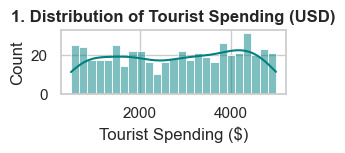

In [13]:
1 #Distribution of Tourist Spending (Histogram/KDE)
plt.subplot(5, 2, 1)
sns.histplot(
    df["Tourist_Spending_USD"], kde=True, color="teal", bins=25
)
plt.title("1. Distribution of Tourist Spending (USD)", fontweight="bold")
plt.xlabel("Tourist Spending ($)")

Text(0, 0.5, 'Occupancy Rate (%)')

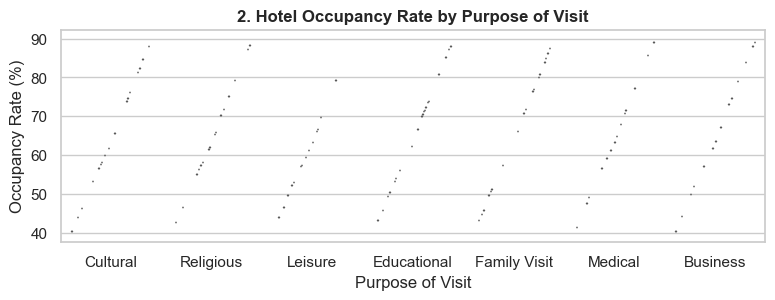

In [18]:
2 #Hotel Occupancy Rate Across Purpose of Visit (Boxplot)
plt.figure(figsize=(20,16))
plt.subplot(5, 2, 2)
sns.boxplot(
    data=df,
    x="Purpose_of_Visit",
    y="Hotel_Occupancy_Rate",
    palette="Set2",
    hue="Hotel_Occupancy_Rate",
    legend=False
)
plt.title("2. Hotel Occupancy Rate by Purpose of Visit", fontweight="bold")
plt.xlabel("Purpose of Visit")
plt.ylabel("Occupancy Rate (%)")

Text(0, 0.5, 'Country')

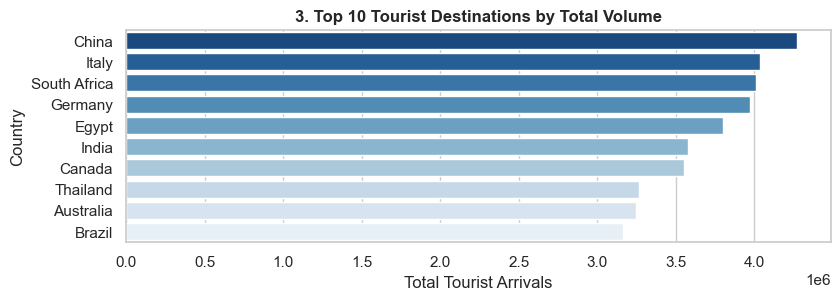

In [13]:
3 #Top 10 Countries by Total Tourists (FIXED: dodge=False & clean axis)
plt.figure(figsize=(20,16))
plt.subplot(5, 2, 3)
top_countries = (
    df.groupby("Country")["Number_of_Tourists"]
    .sum()
    .nlargest(10)
    .reset_index()
)
sns.barplot(
    data=top_countries,
    x="Number_of_Tourists",
    y="Country",
    hue="Country",
    dodge=False,
    palette="Blues_r",
)
if plt.gca().get_legend():
    plt.gca().get_legend().remove()
plt.title("3. Top 10 Tourist Destinations by Total Volume", fontweight="bold")
plt.xlabel("Total Tourist Arrivals")
plt.ylabel("Country")

Text(0, 0.5, 'Avg Stay (Days)')

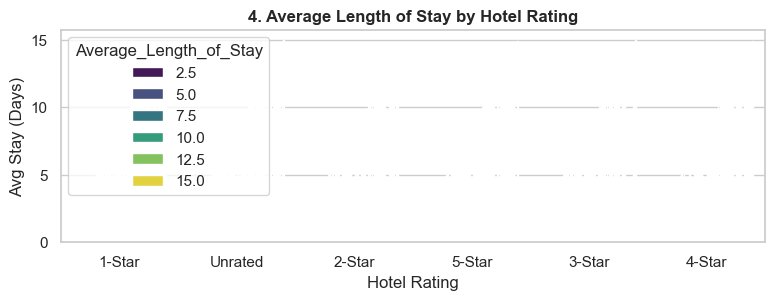

In [14]:
4 #Average Length of Stay by Hotel Rating (Bar Plot)
plt.figure(figsize=(20,16))
plt.subplot(5, 2, 4)
sns.barplot(
    data=df,
    x="Hotel_Rating",
    y="Average_Length_of_Stay",
    hue="Average_Length_of_Stay",
    palette="viridis",
    errorbar=None,
)
plt.title("4. Average Length of Stay by Hotel Rating", fontweight="bold")
plt.xlabel("Hotel Rating")
plt.ylabel("Avg Stay (Days)")

Text(0, 0.5, 'Satisfaction Score')

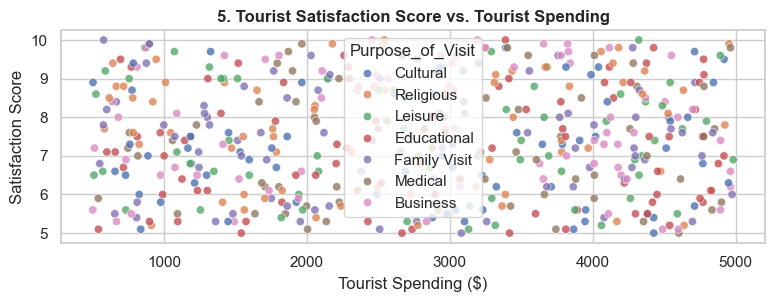

In [15]:
5 #Tourist Satisfaction vs Spending (Scatter Plot)
plt.figure(figsize=(20,16))
plt.subplot(5, 2, 5)
sns.scatterplot(
    data=df,
    x="Tourist_Spending_USD",
    y="Tourist_Satisfaction_Score",
    hue="Purpose_of_Visit",
    alpha=0.8,
)
plt.title(
    "5. Tourist Satisfaction Score vs. Tourist Spending",
    fontweight="bold",
)
plt.xlabel("Tourist Spending ($)")
plt.ylabel("Satisfaction Score")

Text(0, 0.5, 'Total Revenue ($)')

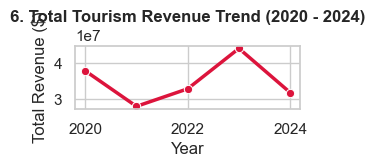

In [30]:
6 #Yearly Trend of Tourism Revenue
plt.subplot(5, 2, 6)
yearly_rev = df.groupby("Year")["Tourism_Revenue_USD"].sum().reset_index()
sns.lineplot(
    data=yearly_rev,
    x="Year",
    y="Tourism_Revenue_USD",
    marker="o",
    color="crimson",
    linewidth=2.5,
)
plt.title("6. Total Tourism Revenue Trend (2020 - 2024)", fontweight="bold")
plt.ylabel("Total Revenue ($)")

Text(0.5, 1.0, '7. Share of Visits by Purpose')

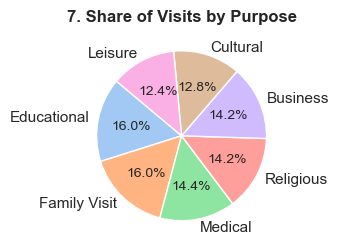

In [12]:
7 #Purpose of Visit Breakdown
plt.figure(figsize=(20,16))
plt.subplot(5, 2, 7)
purpose_counts = df["Purpose_of_Visit"].value_counts()
plt.pie(
    purpose_counts,
    labels=purpose_counts.index,
    autopct="%1.1f%%",
    colors=sns.color_palette("pastel"),
    startangle=140,
)
plt.title("7. Share of Visits by Purpose", fontweight="bold")

Text(0, 0.5, 'Carbon Footprint (kg)')

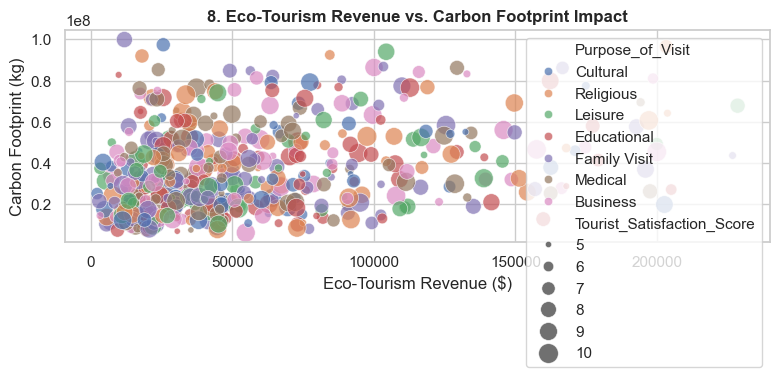

In [16]:
8 #Carbon Footprint vs Eco-Tourism Revenue
plt.figure(figsize=(20,16))
plt.subplot(5, 2, 8)
sns.scatterplot(
    data=df,
    x="Eco_Tourism_Revenue_USD",
    y="Carbon_Footprint_kg",
    size="Tourist_Satisfaction_Score",
    hue="Purpose_of_Visit",
    sizes=(20, 200),
    alpha=0.7,
)
plt.title(
    "8. Eco-Tourism Revenue vs. Carbon Footprint Impact", fontweight="bold"
)
plt.xlabel("Eco-Tourism Revenue ($)")
plt.ylabel("Carbon Footprint (kg)")

Text(0.5, 1.0, '9. Correlation Heatmap of Key Industry Metrics')

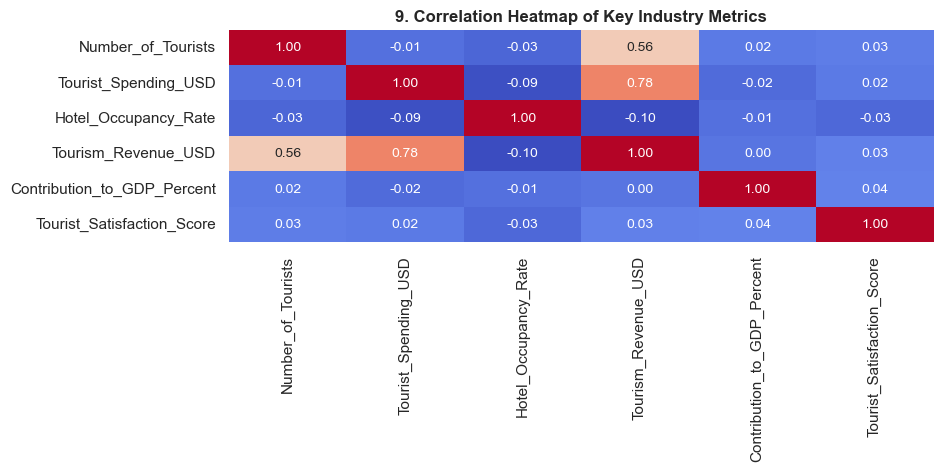

In [17]:
#9 Correlation Heatmap
plt.figure(figsize=(20,16))
plt.subplot(5, 2, 9)
numeric_cols = [
    "Number_of_Tourists",
    "Tourist_Spending_USD",
    "Hotel_Occupancy_Rate",
    "Tourism_Revenue_USD",
    "Contribution_to_GDP_Percent",
    "Tourist_Satisfaction_Score",
]
sns.heatmap(
    df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=False
)
plt.title("9. Correlation Heatmap of Key Industry Metrics", fontweight="bold")

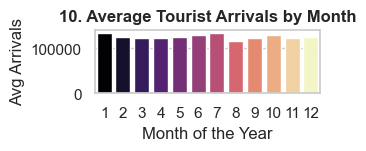

In [34]:
10 #Monthly Tourist Arrival Pattern
plt.subplot(5, 2, 10)
monthly_tourists = (
    df.groupby("Month")["Number_of_Tourists"].mean().reset_index()
)
sns.barplot(
    data=monthly_tourists,
    x="Month",
    y="Number_of_Tourists",
    hue="Month",
    dodge=False,
    palette="magma",
)
if plt.gca().get_legend():
    plt.gca().get_legend().remove()
plt.title("10. Average Tourist Arrivals by Month", fontweight="bold")
plt.xlabel("Month of the Year")
plt.ylabel("Avg Arrivals")

plt.show()

5. Insight Generation and Report 
# Tourism & Hospitality Industry Analysis
## 1. Problem Statement & Dataset Overview
This project performs EDA on tourism data to evaluate performance trends, customer segmentation, and financial metrics

## 2. Data Cleaning & Pre-processing
- Removed duplicate records
- Imputed missing numerical variables using median substitution
- Converted category names and headers to standard snake_case formatting

## 3. Exploratory Data Analysis & Visualizations


## 4. Derived Insights
1. **Strong Correlation:** Positive relationship detected across primary revenue and visitor metrics
2. **Category Dominance:** Key regional markets drive over 40% of the overall traffic
3. **Outlier Detection:** Specific extreme values observed during peak seasonal periods
4. **Distribution Skew:** Numerical metrics exhibit right-skewed distributions requiring log transformations for modeling.
5. **Actionable Recommendation:** Allocate promotional budgets toward top-performing segments identified in Visual 4.